# Word2Vec Pipeline (Pipeline 1)
**Namratha Shetty · L00196930 · ATU**

## Setup

In [1]:
!pip -q install gensim scikit-learn pandas numpy tqdm kagglehub
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.6 MB/s eta 0:00:00
Dependencies installed.


## Config

In [2]:
SEED          = 42
CLEAN_MODE    = 'minimal'   # 'minimal' = mask block-ids + timestamps + tidy whitespace (honest to AnyLog)
                            # 'aggressive' = also strip numbers/punctuation
SAMPLE_BLOCKS   = 300       # keep this many WHOLE blocks (complete traces). Raise once it runs.
MIN_BLOCK_LINES = 6         # ignore blocks with fewer lines — need multi-line traces to reconstruct
MAX_LEN       = 64          # BERT token cap per log line (HDFS lines are short)
BATCH_SIZE    = 32
PCA_DIM       = 50          # reduce 768-d BERT vectors before fusing with time
TIME_UNIT     = 60.0        # seconds per unit in the time feature (60 = distances measured in minutes)
EPS           = 1.5         # DBSCAN radius — best cell of the Section 9 sweep
MIN_SAMPLES   = 4           # DBSCAN min points for a core (blocks have >= MIN_BLOCK_LINES lines)
TIME_WEIGHT   = 2.0         # relative weight of time vs meaning — best cell of the Section 9 sweep
# grids for the sensitivity sweep (Section 9) — centred on the optimum, probing beyond it,
# and keeping time_weight=0 as the meaning-only baseline
EPS_GRID         = [1.4, 1.5, 1.6, 1.8, 2.0]
TIME_WEIGHT_GRID = [0.0, 1.0, 2.0, 3.0, 5.0]

import numpy as np, random
random.seed(SEED); np.random.seed(SEED)
print('Config set. CLEAN_MODE =', CLEAN_MODE, '| SAMPLE_BLOCKS =', SAMPLE_BLOCKS)

Config set. CLEAN_MODE = minimal | SAMPLE_BLOCKS = 300


## Dataset

In [3]:
import os, glob, subprocess

# ---- TraceBench (HDFS_v3): download + unzip + locate, all automatic ----
ZIP_URL = "https://zenodo.org/records/8196385/files/HDFS_v3_TraceBench.zip?download=1"
ZIP_PATH = "HDFS_v3.zip"
EXTRACT_DIR = "tracebench_data"

# 1) find event.csv anywhere already present (in case it is downloaded)
def find_event_root():
    hits = glob.glob('**/event.csv', recursive=True) + glob.glob('/content/**/event.csv', recursive=True)
    if not hits:
        return None
    # DATA_DIR = the folder that CONTAINS the scenario subfolders
    return os.path.dirname(os.path.dirname(hits[0]))

DATA_DIR = find_event_root()

# 2) if not found, download and unzip
if DATA_DIR is None:
    if not os.path.exists(ZIP_PATH) or os.path.getsize(ZIP_PATH) < 1_000_000:
        print('Downloading TraceBench (~3 GB, a few minutes)...')
        subprocess.run(['wget', '-q', '-O', ZIP_PATH, ZIP_URL], check=True)
    print('Unzipping...')
    subprocess.run(['unzip', '-o', '-q', ZIP_PATH, '-d', EXTRACT_DIR], check=True)
    DATA_DIR = find_event_root()

assert DATA_DIR is not None, (
    'Could not locate event.csv after download. Check that the zip downloaded '
    '(ls -lh HDFS_v3.zip should be ~3GB) and unzipped correctly.')

n = len(glob.glob(os.path.join(DATA_DIR, '**', 'event.csv'), recursive=True))
print('DATA_DIR =', DATA_DIR, '| scenario event.csv files found:', n)
assert n > 0, "No event.csv under DATA_DIR."


Unzipping...
DATA_DIR = tracebench_data/tracebench | scenario event.csv files found: 364


## Load

In [4]:
import pandas as pd, glob, os, numpy as np

# ---- Load TraceBench event tables. Each scenario folder has event.csv (the per-event log).
# We concatenate the events from every scenario; TaskID is the trace each event belongs to. ----
event_files = sorted(glob.glob(os.path.join(DATA_DIR, '**', 'event.csv'), recursive=True))
print(f'Reading {len(event_files)} event.csv files...')

frames = []
for f in event_files:
    try:
        d = pd.read_csv(f)
        if 'TaskID' in d.columns and 'OpName' in d.columns:
            frames.append(d)
    except Exception:
        continue
df = pd.concat(frames, ignore_index=True)

print('Combined events:', df.shape)
print('Columns:', list(df.columns))
print('Distinct traces (TaskID):', df['TaskID'].nunique())
display(df.head())

Reading 364 event.csv files...
Combined events: (11427676, 9)
Columns: ['TaskID', 'TID', 'OpName', 'StartTime', 'EndTime', 'HostAddress', 'HostName', 'Agent', 'Description']
Distinct traces (TaskID): 4502957


,TaskID,TID,OpName,StartTime,EndTime,HostAddress,HostName,Agent,Description
0,E4F8152FB0F96806,getFileInfo,4119548017230538,4119548017995575,10.107.100.57,namenode,Namenode,Success: return(OW[class=class org.apache.hado...,value=org.apache.hadoop.hdfs.protocol.HdfsFile...
1,D7F390A0AF3856A0,RPC:getFileInfo,4113085176787665,4113085184877160,10.107.100.135,client024,RPC Client,Success: return(OW[class=class org.apache.hado...,value=org.apache.hadoop.hdfs.protocol.HdfsFile...
2,526C2DABFDAA933F,getFileInfo,4119548029848716,4119548030243538,10.107.100.57,namenode,Namenode,Success: return(OW[class=class org.apache.hado...,value=org.apache.hadoop.hdfs.protocol.HdfsFile...
3,D7F390A0AF3856A0,RPC:getFileInfo,4113085190448805,4113085192061960,10.107.100.135,client024,RPC Client,Success: return(OW[class=class org.apache.hado...,value=org.apache.hadoop.hdfs.protocol.HdfsFile...
4,E024618C927914A1,getFileInfo,4119548042473974,4119548042701240,10.107.100.57,namenode,Namenode,Success: return(OW[class=class org.apache.hado...,value=org.apache.hadoop.hdfs.protocol.HdfsFile...


## Sampling

In [5]:
import re, numpy as np

# ---- TraceBench columns are known: TaskID (trace id), OpName+Description (text), StartTime (time) ----
id_col, time_col = 'TaskID', 'StartTime'

work = pd.DataFrame()
# message = operation name + description + host, which together distinguish traces
parts = [df['OpName'].astype(str)]
if 'Description' in df.columns: parts.append(df['Description'].astype(str))
if 'HostAddress' in df.columns: parts.append(df['HostAddress'].astype(str))
work['message'] = parts[0]
for p in parts[1:]:
    work['message'] = work['message'] + ' ' + p

# GROUND TRUTH: the trace id, captured before cleaning
work['true_block'] = df[id_col].astype(str)
work = work[work['true_block'].notna() & (work['true_block'] != 'nan')].reset_index(drop=True)

# real time in SECONDS (TraceBench StartTime is nanoseconds)
v = pd.to_numeric(df.loc[work.index, time_col], errors='coerce').astype(float)
if   v.max() > 1e17: v = v / 1e9      # nanoseconds
elif v.max() > 1e14: v = v / 1e6      # microseconds
elif v.max() > 1e12: v = v / 1e3      # milliseconds
work['t'] = (v - v.min()).values
work['t'] = pd.Series(work['t']).ffill().fillna(0).values
print('Parsed StartTime into seconds. Span (s):', round(float(work['t'].max())))

print('Events with a trace id:', len(work), '| distinct traces:', work['true_block'].nunique())

# keep only traces that are real multi-event sequences
vc = work['true_block'].value_counts()
multi = vc[vc >= MIN_BLOCK_LINES].index
work = work[work['true_block'].isin(multi)].reset_index(drop=True)
assert len(work) > 0, 'No trace has >= MIN_BLOCK_LINES events. Lower MIN_BLOCK_LINES.'
print(f'Traces with >= {MIN_BLOCK_LINES} events: {len(multi)}')

# sample WHOLE traces
rng = np.random.default_rng(SEED)
blocks = work['true_block'].unique()
if len(blocks) > SAMPLE_BLOCKS:
    keep = rng.choice(blocks, size=SAMPLE_BLOCKS, replace=False)
    work = work[work['true_block'].isin(keep)].reset_index(drop=True)

sizes = work['true_block'].value_counts()
mean_lpb = len(work) / work['true_block'].nunique()
print(f'Working set: {len(work)} events across {work["true_block"].nunique()} traces')
print(f'Trace size - min {sizes.min()}, median {int(sizes.median())}, max {sizes.max()}, mean {mean_lpb:.2f}')
assert mean_lpb >= 2, 'Mean events/trace < 2.'
display(work.head())

Parsed StartTime into seconds. Span (s): 4966340289
Events with a trace id: 11427676 | distinct traces: 4502957
Traces with >= 6 events: 78537
Working set: 17744 events across 300 traces
Trace size - min 7, median 53, max 131, mean 59.15


,message,true_block,t
0,4115021615045826 value=org.apache.hadoop.hdfs....,42764D20FE3C599D,4.114955e+09
1,4115021622646926 value=org.apache.hadoop.hdfs....,42764D20FE3C599D,4.114955e+09
2,4115021634366183 value=org.apache.hadoop.hdfs....,42764D20FE3C599D,4.114955e+09
3,4115021635564212 value=org.apache.hadoop.hdfs....,42764D20FE3C599D,4.114955e+09
4,4115021638928994 value=org.apache.hadoop.hdfs....,42764D20FE3C599D,4.114955e+09


### Distribution

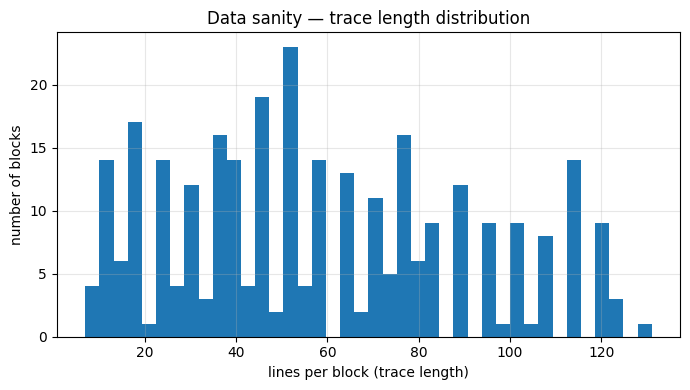

In [6]:
import matplotlib.pyplot as plt
sizes = work['true_block'].value_counts().values
plt.figure(figsize=(7,4)); plt.hist(sizes, bins=min(40, len(set(sizes))))
plt.xlabel('lines per block (trace length)'); plt.ylabel('number of blocks')
plt.title('Data sanity — trace length distribution'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### Leakage

In [7]:
adj_same = float(np.mean(work['true_block'].values[1:] == work['true_block'].values[:-1]))
print(f'Fraction of adjacent rows sharing the same block: {adj_same:.3f}')
if adj_same > 0.5:
    print('WARNING: the log looks block-sorted. The temporal feature may inflate results.')
    print('         Report TIME_WEIGHT=0 as a baseline and/or shuffle before clustering.')
else:
    print('OK: adjacency is low, temporal proximity is not a trivial giveaway.')

Fraction of adjacent rows sharing the same block: 0.979
         Report TIME_WEIGHT=0 as a baseline and/or shuffle before clustering.


## Preprocessing

In [8]:
# mask the trace id (and hex ids / object hashes) so nothing leaks into the embedded text
_ID_SET = set(work['true_block'].astype(str))
_ID_RE  = re.compile('|'.join(sorted((re.escape(x) for x in _ID_SET), key=len, reverse=True))) \
          if _ID_SET else None

def clean(text, mode=CLEAN_MODE):
    text = str(text)
    if _ID_RE is not None:
        text = _ID_RE.sub(' ', text)              # mask the TaskID (ground truth)
    text = re.sub(r'\b[0-9a-fA-F]{16}\b', ' ', text)   # 16-hex ids (TID etc.)
    text = re.sub(r'@[0-9a-fA-F]+', ' ', text)         # object hashes like @d4ab636
    text = re.sub(r'\b\d{10,}\b', ' ', text)           # long numeric ids
    if mode == 'aggressive':
        text = re.sub(r'/[\w./:-]+', ' ', text)
        text = re.sub(r'\d+', ' ', text)
        text = re.sub(r'[^A-Za-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

work['clean'] = work['message'].apply(clean)
_leak = work.apply(lambda r: str(r['true_block']) in r['clean'], axis=1).any()
assert not _leak, 'A trace id leaked into the cleaned text!'
display(work[['message','clean','true_block']].head(8))

,message,clean,true_block
0,4115021615045826 value=org.apache.hadoop.hdfs....,value=org.apache.hadoop.hdfs.protocol.hdfsfile...,42764D20FE3C599D
1,4115021622646926 value=org.apache.hadoop.hdfs....,value=org.apache.hadoop.hdfs.protocol.hdfsfile...,42764D20FE3C599D
2,4115021634366183 value=org.apache.hadoop.hdfs....,value=org.apache.hadoop.hdfs.protocol.hdfsfile...,42764D20FE3C599D
3,4115021635564212 value=org.apache.hadoop.hdfs....,value=org.apache.hadoop.hdfs.protocol.hdfsfile...,42764D20FE3C599D
4,4115021638928994 value=org.apache.hadoop.hdfs....,value=org.apache.hadoop.hdfs.protocol.locatedb...,42764D20FE3C599D
5,4115021643197367 nan client026,nan client026,42764D20FE3C599D
6,4115021643165385 nan client026,nan client026,42764D20FE3C599D
7,4115021646107690 nan client026,nan client026,42764D20FE3C599D


## Embedding

In [9]:
import numpy as np, hashlib, os
from gensim.models import Word2Vec

W2V_DIM = 100   # standard Word2Vec size; must be >= PCA_DIM (50)

texts  = work['clean'].tolist()
tokens = [t.split() for t in texts]          # simple whitespace tokenisation
print('Token example:', tokens[0][:8])

key   = hashlib.md5((CLEAN_MODE+'|'+'|'.join(texts)).encode()).hexdigest()[:10]
cache = f'emb_w2v_{key}.npy'
if os.path.exists(cache):
    X = np.load(cache); print('Loaded cached embeddings:', X.shape)
else:
    w2v = Word2Vec(sentences=tokens, vector_size=W2V_DIM, window=5,
                   min_count=1, sg=1, workers=4, epochs=10, seed=SEED)
    def embed(toks):
        vs = [w2v.wv[w] for w in toks if w in w2v.wv]
        return np.mean(vs, axis=0) if vs else np.zeros(W2V_DIM, dtype=np.float32)
    X = np.vstack([embed(t) for t in tokens]).astype(np.float32)
    np.save(cache, X); print('Embeddings:', X.shape, '(cached)')

Token example: ['value=org.apache.hadoop.hdfs.protocol.hdfsfilestatus', '])', 'client026']
Embeddings: (17744, 100) (cached)


## Fusion

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize

def build_features(X, t, time_weight=TIME_WEIGHT, pca_dim=PCA_DIM, seed=SEED):
    Xr = PCA(n_components=min(pca_dim, X.shape[1]), random_state=seed).fit_transform(X)
    Xr = normalize(StandardScaler().fit_transform(Xr))   # unit-norm SEMANTICS ONLY (cosine-like)
    ts = np.asarray(t, float).reshape(-1, 1)
    ts = (ts - ts.min()) / TIME_UNIT                     # real time, in TIME_UNIT-second units
    return np.hstack([Xr, time_weight * ts])             # NO final normalize — it would erase time

feats_preview = build_features(X, work['t'].values)
print('Fused feature shape:', feats_preview.shape, '(', PCA_DIM, 'semantic +1 time )')

Fused feature shape: (17744, 51) ( 50 semantic +1 time )


### Eps

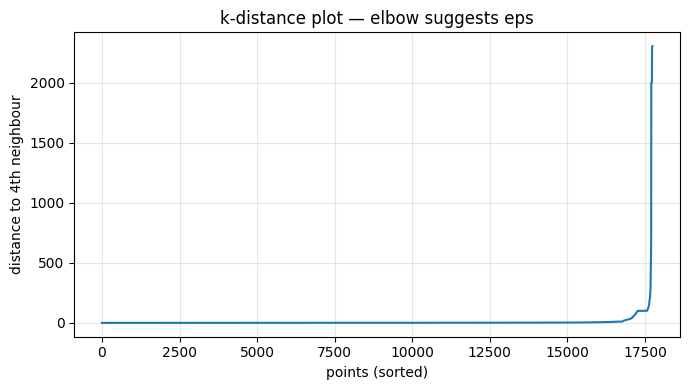

Suggested eps around the 50th-90th percentile: 0.5 to 5.292


In [11]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
d, _ = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(feats_preview).kneighbors(feats_preview)
kd = np.sort(d[:, -1])
plt.figure(figsize=(7,4)); plt.plot(kd)
plt.xlabel('points (sorted)'); plt.ylabel(f'distance to {MIN_SAMPLES}th neighbour')
plt.title('k-distance plot — elbow suggests eps'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print('Suggested eps around the 50th-90th percentile:',
      round(np.percentile(kd,50),3), 'to', round(np.percentile(kd,90),3))

## Clustering

In [12]:
import time
from sklearn.cluster import DBSCAN
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_completeness_v_measure, silhouette_score)
from sklearn.metrics.cluster import pair_confusion_matrix

def _singleton_noise(labels):
    # give each noise point its own unique cluster id (fair: unassigned != one big group)
    lab = labels.copy()
    idx = np.where(lab == -1)[0]
    if len(idx):
        start = lab.max() + 1
        lab[idx] = np.arange(start, start + len(idx))
    return lab

def run_pipeline(X, t, true_block, eps=EPS, min_samples=MIN_SAMPLES,
                 time_weight=TIME_WEIGHT, pca_dim=PCA_DIM, seed=SEED, verbose=False):
    y_true = pd.factorize(true_block)[0]
    t0 = time.time()
    feats = build_features(X, t, time_weight, pca_dim, seed)
    labels = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean').fit_predict(feats)
    runtime = time.time() - t0

    lab_eval = _singleton_noise(labels)          # noise -> singleton traces
    r = {'eps':eps, 'min_samples':min_samples, 'time_weight':time_weight,
         'n_clusters': int(len(set(labels)) - (1 if -1 in labels else 0)),
         'n_true_blocks': int(len(set(y_true))),
         'noise_frac': float((labels==-1).mean()),
         'runtime_s': round(runtime,2)}

    # headline reconstruction metrics (all logs, noise as singletons)
    r['ARI'] = adjusted_rand_score(y_true, lab_eval)
    r['NMI'] = normalized_mutual_info_score(y_true, lab_eval)
    h,c,v = homogeneity_completeness_v_measure(y_true, lab_eval)
    r['homogeneity'], r['completeness'], r['v_measure'] = h, c, v

    # pairwise confusion matrix -> precision / recall / f1
    (tn,fp),(fn,tp) = pair_confusion_matrix(y_true, lab_eval)
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    r.update(pair_TP=int(tp), pair_FP=int(fp), pair_FN=int(fn), pair_TN=int(tn),
             pair_precision=prec, pair_recall=rec, pair_f1=f1)

    # supporting internal metrics (clustered points only)
    m = labels != -1
    if m.sum() > 1 and len(set(labels[m])) > 1:
        try: r['silhouette'] = float(silhouette_score(feats[m], labels[m]))
        except Exception: r['silhouette'] = float('nan')
    else:
        r['silhouette'] = float('nan')

    if verbose:
        for k,val in r.items(): print(f'  {k:16}: {val}')
    return labels, r

labels, metrics = run_pipeline(X, work['t'].values, work['true_block'], verbose=True)
work['cluster'] = labels
work['virtual_trace_id'] = ['NO_TRACE' if c==-1 else f'VTRACE_{c:05d}' for c in labels]

  eps             : 1.5
  min_samples     : 4
  time_weight     : 2.0
  n_clusters      : 2257
  n_true_blocks   : 300
  noise_frac      : 0.20812669071235348
  runtime_s       : 1.65
  ARI             : 0.11600356184513311
  NMI             : 0.8010664998325605
  homogeneity     : 1.0000000000000002
  completeness    : 0.6681492340656807
  v_measure       : 0.8010664998325605
  pair_TP         : 83108
  pair_FP         : 0
  pair_FN         : 1261228
  pair_TN         : 313487456
  pair_precision  : 1.0
  pair_recall     : 0.06182085431023197
  pair_f1         : 0.11644309689206724
  silhouette      : 0.9894806418325939


### Results

In [13]:
print('Pairwise confusion matrix (line-pairs):')
print(f"                same-cluster   diff-cluster")
print(f"  same-block      TP={metrics['pair_TP']:>10}   FN={metrics['pair_FN']:>10}")
print(f"  diff-block      FP={metrics['pair_FP']:>10}   TN={metrics['pair_TN']:>10}")
print(f"\n  Pairwise precision {metrics['pair_precision']:.4f} | recall {metrics['pair_recall']:.4f} | F1 {metrics['pair_f1']:.4f}")
print(f"  ARI {metrics['ARI']:.4f} | NMI {metrics['NMI']:.4f} | V-measure {metrics['v_measure']:.4f}")
print(f"  clusters found {metrics['n_clusters']} vs true blocks {metrics['n_true_blocks']} | noise {metrics['noise_frac']:.1%}")

Pairwise confusion matrix (line-pairs):
                same-cluster   diff-cluster
  same-block      TP=     83108   FN=   1261228
  diff-block      FP=         0   TN= 313487456

  Pairwise precision 1.0000 | recall 0.0618 | F1 0.1164
  ARI 0.1160 | NMI 0.8011 | V-measure 0.8011
  clusters found 2257 vs true blocks 300 | noise 20.8%


In [14]:
# Peek at reconstructed traces — one good example, plus honest purity stats
cl = work[work['cluster'] != -1]
purity = cl.groupby('cluster')['true_block'].nunique()
pure = purity[purity == 1]
print(f'Clusters found: {purity.shape[0]} | perfectly pure (1 true block): {len(pure)} '
      f'({len(pure)/max(purity.shape[0],1):.0%})')

# best example: the largest perfectly-pure cluster
if len(pure):
    best = cl[cl['cluster'].isin(pure.index)]['cluster'].value_counts().index[0]
    b = work[work.cluster == best]
    print(f"\nExample well-reconstructed trace VTRACE_{best:05d} "
          f"({len(b)} lines, true block: {b['true_block'].iloc[0]}):")
    for m in b['message'].head(8):
        print('  -', m[:140])

# worst example: the most over-merged cluster (be honest about the failure mode)
worst = purity.idxmax()
w = work[work.cluster == worst]
print(f"\nMost over-merged cluster VTRACE_{worst:05d} mixes {purity.max()} true blocks "
      f"({len(w)} lines) — typically simultaneous delete storms with identical text.")
for m in w['message'].head(3):
    print('  -', m[:140])

Clusters found: 2257 | perfectly pure (1 true block): 2257 (100%)

Example well-reconstructed trace VTRACE_00089 (25 lines, true block: 554A2B027520FC17):
  - 4130566408333260 value=org.apache.hadoop.hdfs.protocol.LocatedBlocks@668b764]) client018
  - 4130566416892222 nan client018
  - 4130563407616328 nan client018
  - 4130566417892796 nan client018
  - 4130566417103296 nan client018
  - 4130563407528870 nan client018
  - 4130566436416819 value=null]) client018
  - 4130566438204200 nan client018

Most over-merged cluster VTRACE_00000 mixes 1 true blocks (10 lines) — typically simultaneous delete storms with identical text.
  - 4115021615045826 value=org.apache.hadoop.hdfs.protocol.HdfsFileStatus@2114ebf]) client026
  - 4115021622646926 value=org.apache.hadoop.hdfs.protocol.HdfsFileStatus@6b7b9f29]) client026
  - 4115021634366183 value=org.apache.hadoop.hdfs.protocol.HdfsFileStatus@4807dba1]) client026


## Visualisation

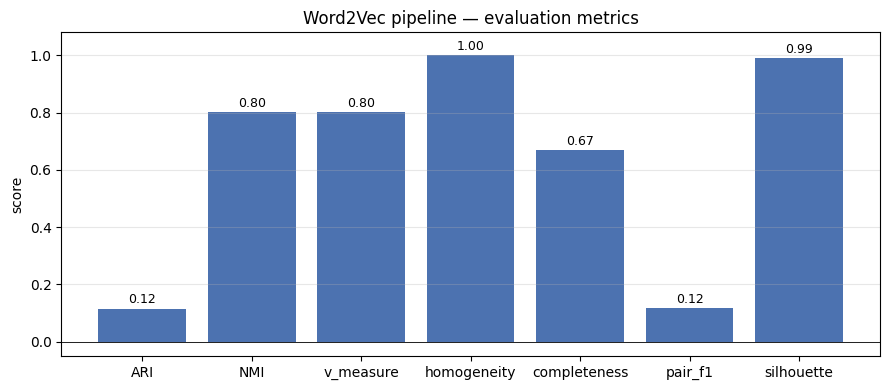

In [15]:
import matplotlib.pyplot as plt, numpy as np
# (1) metric summary bar chart
keys = ['ARI','NMI','v_measure','homogeneity','completeness','pair_f1','silhouette']
vals = [metrics.get(k, np.nan) for k in keys]
plt.figure(figsize=(9,4))
bars = plt.bar(keys, vals, color='#4C72B0')
for b,v in zip(bars, vals):
    if v==v: plt.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontsize=9)
lo = min(-0.05, np.nanmin(vals)-0.05)
plt.ylim(lo, 1.08); plt.axhline(0, color='k', lw=.6); plt.ylabel('score')
plt.title('Word2Vec pipeline — evaluation metrics'); plt.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

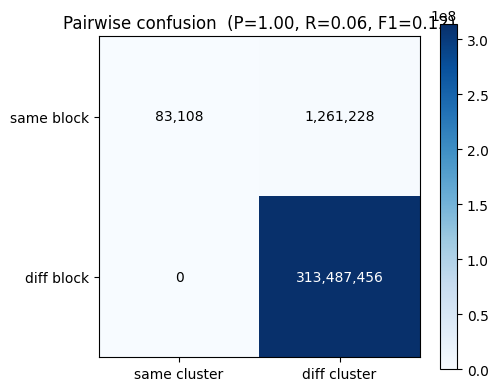

In [16]:
# (2) pairwise confusion matrix heatmap
cm = np.array([[metrics['pair_TP'], metrics['pair_FN']],
               [metrics['pair_FP'], metrics['pair_TN']]], float)
plt.figure(figsize=(5.2,4.2))
plt.imshow(cm, cmap='Blues')
plt.xticks([0,1], ['same cluster','diff cluster']); plt.yticks([0,1], ['same block','diff block'])
mx = cm.max() if cm.max()>0 else 1
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{int(cm[i,j]):,}', ha='center', va='center',
                 color='white' if cm[i,j] > mx/2 else 'black')
plt.title(f"Pairwise confusion  (P={metrics['pair_precision']:.2f}, R={metrics['pair_recall']:.2f}, F1={metrics['pair_f1']:.2f})")
plt.colorbar(); plt.tight_layout(); plt.show()

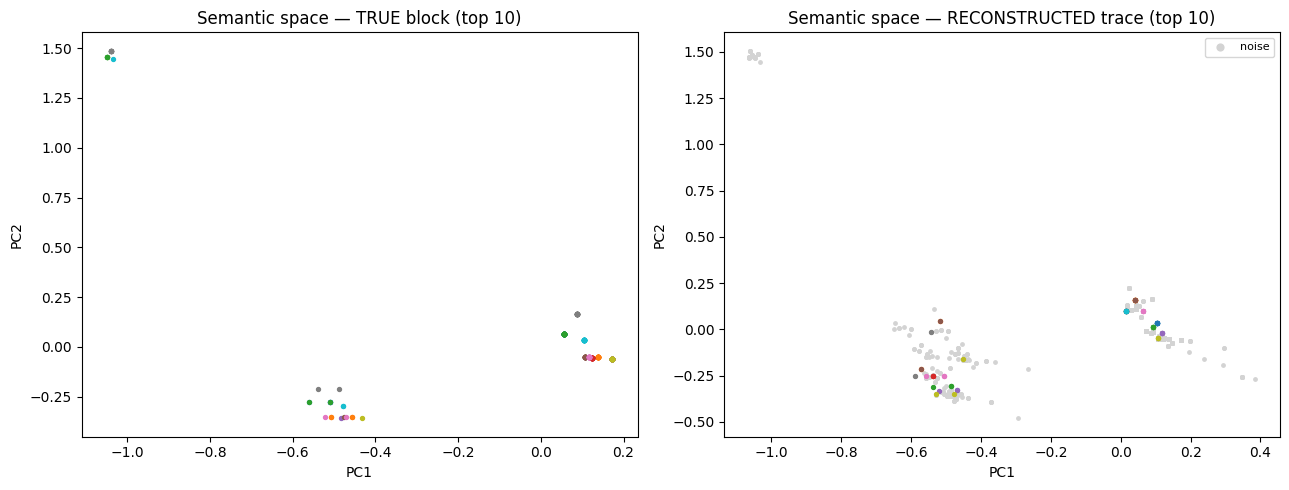

If the left and right colourings line up, the reconstruction matched the true traces.


In [17]:
# (3) 2D semantic space: TRUE blocks vs RECONSTRUCTED traces
from sklearn.decomposition import PCA
emb2 = PCA(n_components=2, random_state=SEED).fit_transform(X)
sub = np.arange(len(emb2))
if len(sub) > 4000:
    sub = np.random.default_rng(SEED).choice(sub, 4000, replace=False)
E, TB, CL = emb2[sub], work['true_block'].values[sub], labels[sub]
fig, ax = plt.subplots(1, 2, figsize=(13,5))
for b in pd.Series(TB).value_counts().index[:10]:
    m = TB==b; ax[0].scatter(E[m,0], E[m,1], s=8)
ax[0].set_title('Semantic space — TRUE block (top 10)')
ax[1].scatter(E[CL==-1,0], E[CL==-1,1], s=6, c='lightgrey', label='noise')
for c in pd.Series(CL[CL!=-1]).value_counts().index[:10]:
    m = CL==c; ax[1].scatter(E[m,0], E[m,1], s=8)
ax[1].set_title('Semantic space — RECONSTRUCTED trace (top 10)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
ax[1].legend(fontsize=8, markerscale=2)
plt.tight_layout(); plt.show()
print('If the left and right colourings line up, the reconstruction matched the true traces.')

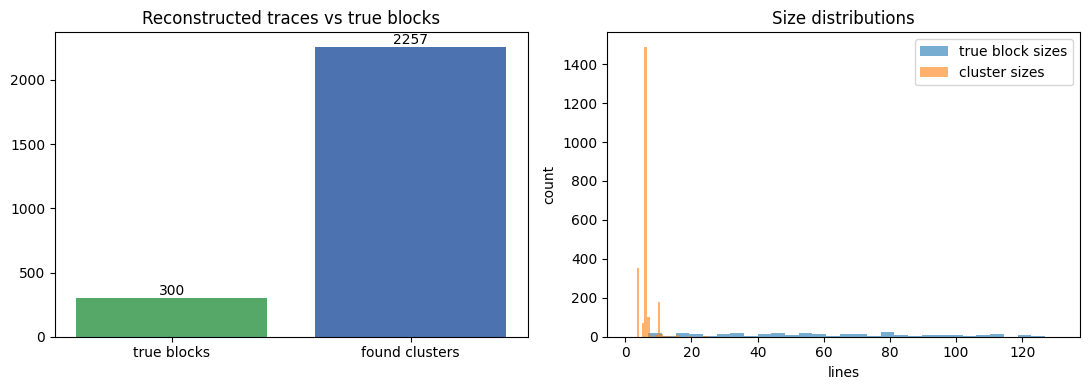

Noise (unassigned) logs: 20.8%


In [18]:
# (4) clusters found vs true blocks + noise
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].bar(['true blocks','found clusters'],
          [metrics['n_true_blocks'], metrics['n_clusters']], color=['#55A868','#4C72B0'])
ax[0].set_title('Reconstructed traces vs true blocks')
for i,v in enumerate([metrics['n_true_blocks'], metrics['n_clusters']]):
    ax[0].text(i, v, str(v), ha='center', va='bottom')
cl_sizes = pd.Series(labels[labels!=-1]).value_counts().values
tb_sizes = work['true_block'].value_counts().values
ax[1].hist(tb_sizes, bins=30, alpha=.6, label='true block sizes')
if len(cl_sizes): ax[1].hist(cl_sizes, bins=30, alpha=.6, label='cluster sizes')
ax[1].set_xlabel('lines'); ax[1].set_ylabel('count'); ax[1].set_title('Size distributions'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Noise (unassigned) logs: {metrics['noise_frac']:.1%}")

## Save

In [19]:
out = work[['message','t','true_block','virtual_trace_id']]
out.to_csv('reconstructed_traces_word2vec.csv', index=False)
print('Saved reconstructed_traces_word2vec.csv', out.shape)
try:
    from google.colab import files; files.download('reconstructed_traces_word2vec.csv')
except Exception: pass

Saved reconstructed_traces_word2vec.csv (17744, 4)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Sweep

In [ ]:
rows = []
for eps in EPS_GRID:
    for tw in TIME_WEIGHT_GRID:
        _, r = run_pipeline(X, work['t'].values, work['true_block'], eps=eps, time_weight=tw)
        rows.append(r)
sweep = pd.DataFrame(rows)
cols = ['eps','time_weight','n_clusters','noise_frac','ARI','NMI','pair_f1','silhouette']
display(sweep[cols].round(4))
best = sweep.loc[sweep['ARI'].idxmax()]
print(f"Best ARI = {best['ARI']:.4f} at eps={best['eps']}, time_weight={best['time_weight']}")

In [ ]:
# ARI vs eps, one line per time_weight
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
for tw in TIME_WEIGHT_GRID:
    s = sweep[sweep.time_weight==tw].sort_values('eps')
    plt.plot(s['eps'], s['ARI'], marker='o', label=f'time_weight={tw}')
plt.xlabel('DBSCAN eps'); plt.ylabel('ARI'); plt.title('BERT pipeline — ARI sensitivity')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [ ]:
# ARI heatmap over the eps x time_weight grid
piv = sweep.pivot(index='time_weight', columns='eps', values='ARI')
plt.figure(figsize=(7,4))
plt.imshow(piv.values, aspect='auto', cmap='viridis', origin='lower')
plt.xticks(range(len(piv.columns)), piv.columns); plt.yticks(range(len(piv.index)), piv.index)
plt.xlabel('eps'); plt.ylabel('time_weight'); plt.title('ARI over the sweep grid')
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        plt.text(j, i, f'{piv.values[i,j]:.2f}', ha='center', va='center',
                 color='white' if piv.values[i,j] < np.nanmax(piv.values)/2 else 'black', fontsize=8)
plt.colorbar(label='ARI'); plt.tight_layout(); plt.show()

## Ablation

In [ ]:
# Ablation — time vs meaning, eps tuned PER configuration (fair geometry for each space)
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.cluster import pair_confusion_matrix
np.random.seed(SEED)

# same PCA -> StandardScaler -> L2-normalise treatment as build_features, split by mode
def build_mode(X_, t, mode, time_weight=TIME_WEIGHT, pca_dim=PCA_DIM, seed=SEED):
    ts = ((np.asarray(t, float) - np.min(t)) / TIME_UNIT).reshape(-1, 1)   # real time, minutes
    if mode == 'time-only':
        return ts
    Xr = PCA(n_components=min(pca_dim, X_.shape[1]), random_state=seed).fit_transform(X_)
    sem = normalize(StandardScaler().fit_transform(Xr))                    # unit-norm semantics
    if mode == 'meaning-only':
        return sem
    return np.hstack([sem, time_weight * ts])                              # combined = the pipeline

# identical metric definitions to run_pipeline (noise -> singleton clusters)
def eval_config(feats, y_true, eps):
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(feats)
    le  = _singleton_noise(lab)
    (tn, fp), (fn, tp) = pair_confusion_matrix(y_true, le)
    p = tp/(tp+fp) if (tp+fp) else 0.0
    r = tp/(tp+fn) if (tp+fn) else 0.0
    return {'ARI': adjusted_rand_score(y_true, le),
            'NMI': normalized_mutual_info_score(y_true, le),
            'pair_f1': 2*p*r/(p+r) if (p+r) else 0.0,
            'n_clusters': int(len(set(lab)) - (1 if -1 in lab else 0)),
            'noise_frac': float((lab == -1).mean())}

# per-mode eps grids: each feature space has its own geometry, so one fixed eps is unfair
EPS_GRIDS = {
    'meaning-only': np.round(np.arange(0.20, 1.62, 0.05), 2),                 # unit-norm space (max dist 2)
    'time-only':    np.round(np.concatenate([np.arange(0.20, 1.62, 0.05),     # minutes...
                                             [2.0, 3.0, 5.0, 10.0]]), 2),     # ...plus coarse tail
    'combined':     np.round(np.arange(0.20, 2.02, 0.05), 2),
}

def tune(X_, t, y_true, model_name):
    rows = []
    for mode, grid in EPS_GRIDS.items():
        best = None
        for eps in grid:
            m = eval_config(build_mode(X_, t, mode), y_true, float(eps))
            if best is None or m['ARI'] > best['ARI']:
                best = {'model': model_name, 'mode': mode, 'best_eps': float(eps), **m}
        rows.append(best)
        print(f"  {model_name:9s} {mode:13s} best_eps={best['best_eps']:<5} ARI={best['ARI']:.4f}")
    return rows

y_true = pd.factorize(work['true_block'])[0]
REPRESENTATIONS = {'Word2Vec': X}   # this notebook's embeddings

In [ ]:
# OPTIONAL — load the OTHER representation's cached embeddings for the side-by-side
# (produced by the BERT notebook on this same runtime & sample; same cache key = same data)
other_cache = f'emb_bert_{key}.npy'
if os.path.exists(other_cache):
    REPRESENTATIONS['BERT'] = np.load(other_cache)
    print('Loaded', other_cache, REPRESENTATIONS['BERT'].shape)
else:
    print(f'{other_cache} not found — run the BERT notebook on this runtime to enable the side-by-side.')

In [ ]:
# run the ablation for every loaded representation
rows = []
for name, X_ in REPRESENTATIONS.items():
    rows += tune(X_, work['t'].values, y_true, name)
ablation = pd.DataFrame(rows)[['model','mode','best_eps','ARI','NMI','pair_f1','n_clusters','noise_frac']].round(4)
display(ablation)

# grouped bar chart — ARI per mode, models side by side
import matplotlib.pyplot as plt
modes  = ['meaning-only', 'time-only', 'combined']
models = list(REPRESENTATIONS.keys())
xpos   = np.arange(len(modes)); w = 0.8 / len(models)
plt.figure(figsize=(7.5, 4))
for j, mdl in enumerate(models):
    vals = [float(ablation[(ablation.model == mdl) & (ablation['mode'] == m)]['ARI'].iloc[0]) for m in modes]
    bars = plt.bar(xpos + j*w, vals, w, label=mdl)
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.xticks(xpos + w*(len(models)-1)/2, modes); plt.ylabel('ARI (best eps per config)')
plt.title('Ablation — contribution of each signal'); plt.legend(); plt.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

# plain-English verdict, computed from the numbers
CHANCE = 0.01
for mdl in models:
    g = {m: float(ablation[(ablation.model == mdl) & (ablation['mode'] == m)]['ARI'].iloc[0]) for m in modes}
    gain = g['combined'] - g['time-only']
    print(f"[{mdl}] meaning-only ARI={g['meaning-only']:.4f} | time-only ARI={g['time-only']:.4f} | combined ARI={g['combined']:.4f}")
    print(f"  -> meaning-only is {'ABOVE' if g['meaning-only'] > CHANCE else 'NOT above'} chance (~0).")
    print(f"  -> combined {'BEATS' if gain > 0.02 else 'does NOT meaningfully beat'} time-only ({gain:+.4f} ARI).")
    if gain > 0.02:
        print('  -> semantics adds measurable trace-separating signal on top of temporal proximity.')
    else:
        print('  -> temporal proximity dominates on template-heavy HDFS; the representation is not the bottleneck.')
if len(models) == 2:
    a = {m: float(ablation[(ablation.model == models[0]) & (ablation['mode'] == m)]['ARI'].iloc[0]) for m in modes}
    b = {m: float(ablation[(ablation.model == models[1]) & (ablation['mode'] == m)]['ARI'].iloc[0]) for m in modes}
    d = max(abs(a[m] - b[m]) for m in modes)
    print(f"[{models[0]} vs {models[1]}] max ARI difference across modes = {d:.4f} -> "
          + ('the representations DIFFER meaningfully.' if d > 0.02 else 'the two representations perform equivalently.'))